# Four-Point Probe Sheet Resistance Measurements

Sheet resistance is a measure of how easily electric current flows across a material's surface, reported in ohms per square (Ω/□). The four-point probe technique separates current-carrying and voltage-sensing into different probe pairs, so contact resistance drops out of the measurement entirely.

56 valid readings were collected at 9 µA across 9 conductive samples. Readings fluctuated significantly — the broad ranges reflect display instability rather than true differences between measurement points.

## 1. Setup

In [1]:
import pandas as pd, matplotlib.pyplot as plt, os

LOCAL = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'four_point_probe_readings.csv')
GITHUB = 'https://raw.githubusercontent.com/vivianweidai/research/main/20260404%20Four%20Point%20Probe/OUTPUT/four_point_probe_readings.csv'
SAVE = os.path.exists(LOCAL)

def save(path):
    if SAVE:
        plt.savefig(path, dpi=300, bbox_inches='tight')

df = pd.read_csv(LOCAL) if os.path.exists(LOCAL) else pd.read_csv(GITHUB)
valid = df[(df['current_uA'] == 9) & df['sheet_resistance_ohm_per_sq'].notna()].copy()
print(f'Total readings: {len(df)}, valid 9µA: {len(valid)}, excluded: {len(df) - len(valid)}')

Total readings: 65, valid 9µA: 56, excluded: 9


## 2. Summary Statistics

Mean sheet resistance (Ω/□) for each sample, ranked from most to least conductive. The quarter (nickel-clad copper) and stainless steel spoon were the most conductive; the brass house key was the least conductive metal. All non-metals were too resistive to measure.

In [2]:
stats = valid.groupby(['sample', 'material'])['sheet_resistance_ohm_per_sq'].agg(
    n='count', mean='mean', min='min', max='max'
).sort_values('mean').reset_index()

stats['mean_str'] = stats['mean'].map('{:.1f}'.format)
stats['range_str'] = stats.apply(lambda r: f"{r['min']:.1f}–{r['max']:.1f}", axis=1)
stats['err_lo'] = stats['mean'] - stats['min']
stats['err_hi'] = stats['max'] - stats['mean']

print(f"{'Sample':<28} {'Material':<22} {'n':>3}  {'Mean':>6}  {'Range'}")
print('—' * 75)
for _, r in stats.iterrows():
    print(f"{r['sample']:<28} {r['material']:<22} {r['n']:>3}  {r['mean_str']:>6}  {r['range_str']}")

Sample                       Material                 n    Mean  Range
———————————————————————————————————————————————————————————————————————————
quarter                      nickel-clad copper       2    37.8  37.6–37.9
stainless steel spoon        stainless steel          7    39.0  36.6–41.5
penny (unpolished)           copper-plated zinc       3    47.3  44.5–48.9
aluminum foil                aluminum                 5    48.1  47.6–48.7
penny (semi-polished)        copper-plated zinc      10    48.6  46.1–51.8
penny (fully polished)       copper-plated zinc      16    50.1  47.5–55.7
aluminum foil (flipped)      aluminum                 3    54.7  52.8–56.2
metal washer                 steel                    5    54.8  53.2–56.2
house key                    brass                    5    57.2  56.1–58.3


## 3. Mean Sheet Resistance by Sample

Horizontal bar chart with min–max range error bars. Lower values = more conductive. Sanding the penny increased resistance (copper more conductive than zinc, though ranges overlap). Flipping the aluminum foil increased resistance from 48.1 to 54.7 Ω/□ — the matte and shiny sides have measurably different surface conductivity.

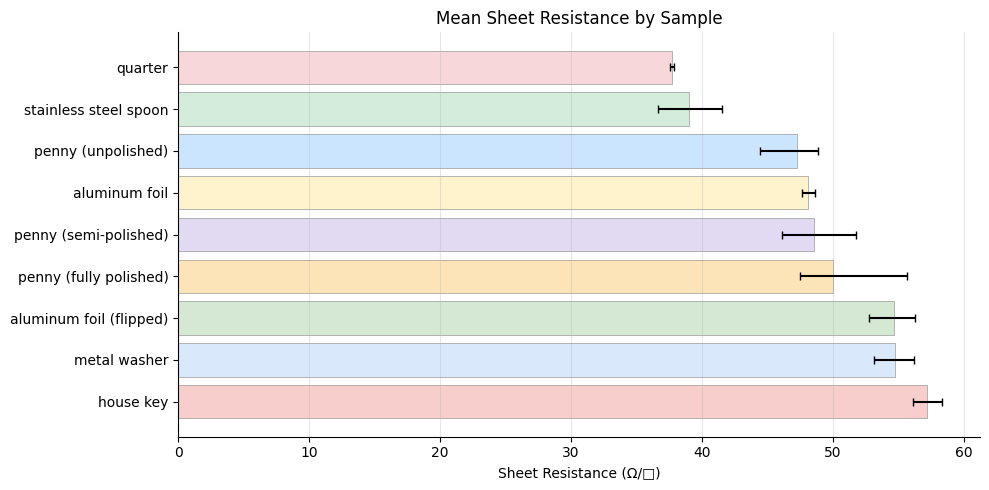

In [3]:
COLORS = ['#f8d7da', '#d4edda', '#cce5ff', '#fff3cd', '#e2d9f3',
          '#fce4b8', '#d5e8d4', '#dae8fc', '#f8cecc', '#e1d5e7']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(stats['sample'], stats['mean'],
               xerr=[stats['err_lo'], stats['err_hi']],
               color=COLORS[:len(stats)], capsize=3, edgecolor='#999', linewidth=0.5)
ax.set_xlabel('Sheet Resistance (Ω/□)')
ax.set_title('Mean Sheet Resistance by Sample')
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save('mean_sheet_resistance.png')
plt.show()

---

<a href="https://colab.research.google.com/github/vivianweidai/research/blob/main/20260404%20Four%20Point%20Probe/OUTPUT/four_point_probe_analysis.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align:middle;"></a>